<a href="https://colab.research.google.com/github/kaylatucker/CS690_Capstone/blob/main/03_notebooks/07_seller_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seller EDA

### Loading Data

In [1]:
!git clone https://github.com/kaylatucker/CS690_Capstone.git

Cloning into 'CS690_Capstone'...
remote: Enumerating objects: 209, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 209 (delta 89), reused 23 (delta 11), pack-reused 40 (from 4)
Receiving objects: 100% (209/209), 84.83 MiB | 19.66 MiB/s, done.
Resolving deltas: 100% (91/91), done.
Updating files: 100% (45/45), done.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO_DIR = Path("/content/CS690_Capstone")
PROCESSED_DIR = REPO_DIR / "02_data" / "processed"

seller_metrics = pd.read_csv(
    PROCESSED_DIR / "seller_metrics.csv",
    dtype={"seller_zip_code_prefix": str}
)

print("Rows:", len(seller_metrics))
print("Unique sellers:", seller_metrics["seller_id"].nunique())
print("Duplicate seller IDs:", seller_metrics["seller_id"].duplicated().sum())

Rows: 3095
Unique sellers: 3095
Duplicate seller IDs: 0


### Summary Statistics

In [3]:
seller_fields = [
    "seller_order_count",
    "seller_items_sold",
    "seller_total_sales",
    "seller_avg_item_value",
    "seller_product_count",
    "seller_category_count",
    "seller_total_freight",
    "seller_avg_freight",
    "seller_average_review",
    "seller_late_delivery_rate"
]

seller_summary = (
    seller_metrics[seller_fields]
    .describe()
    .T
    .round(2)
)

display(seller_summary)

,count,mean,std,min,25%,50%,75%,max
seller_order_count,3095.0,32.31,105.14,1.00,2.00,6.00,21.50,1854.00
seller_items_sold,3095.0,36.40,119.19,1.00,2.00,8.00,24.00,2033.00
seller_total_sales,3095.0,4391.48,13922.00,3.50,208.85,821.48,3280.83,229472.63
seller_avg_item_value,3095.0,176.33,322.15,3.50,52.18,95.47,173.99,6729.00
seller_product_count,3095.0,11.13,24.47,1.00,2.00,4.00,10.00,399.00
seller_category_count,3095.0,2.05,2.10,0.00,1.00,1.00,2.00,27.00
seller_total_freight,3095.0,727.60,2327.16,6.66,46.17,155.52,558.17,51612.55
seller_avg_freight,3095.0,23.38,18.96,1.20,14.74,18.23,24.37,308.34
seller_average_review,3073.0,4.04,0.95,1.00,3.83,4.24,4.67,5.00
seller_late_delivery_rate,2948.0,0.09,0.17,0.00,0.00,0.00,0.11,1.00


### Check skewness

In [4]:
seller_skewness = (
    seller_metrics[seller_fields]
    .skew(numeric_only=True)
    .sort_values(ascending=False)
    .round(2)
)

display(
    seller_skewness.to_frame("skewness")
)

,skewness
seller_total_freight,10.55
seller_items_sold,9.79
seller_order_count,9.64
seller_total_sales,9.05
seller_avg_item_value,8.71
seller_product_count,6.64
seller_avg_freight,5.23
seller_category_count,3.86
seller_late_delivery_rate,3.54
seller_average_review,-1.73


### Seller sales distribution

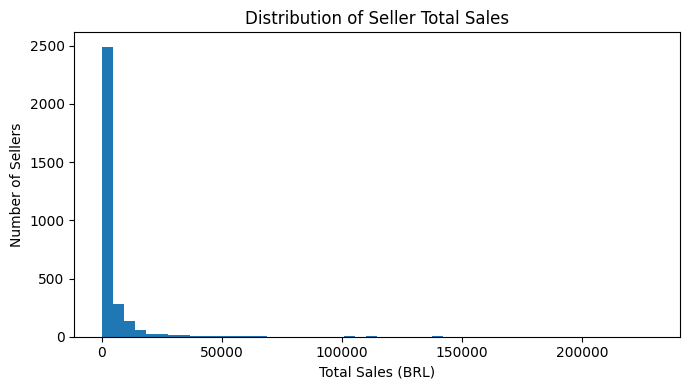

In [9]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_total_sales"].dropna(),
    bins=50
)

plt.title("Distribution of Seller Total Sales")
plt.xlabel("Total Sales (BRL)")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

### Seller order-count distribution

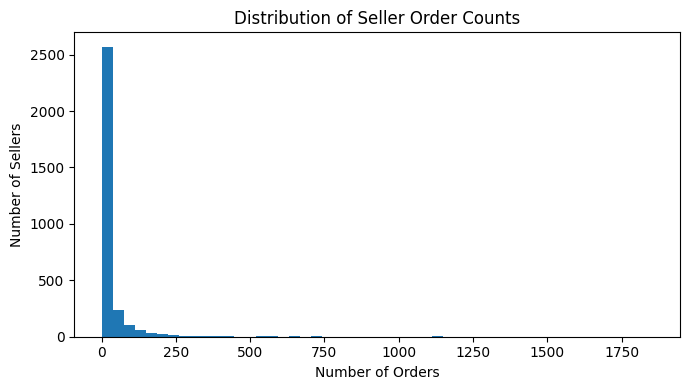

In [7]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_order_count"].dropna(),
    bins=50
)

plt.title("Distribution of Seller Order Counts")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

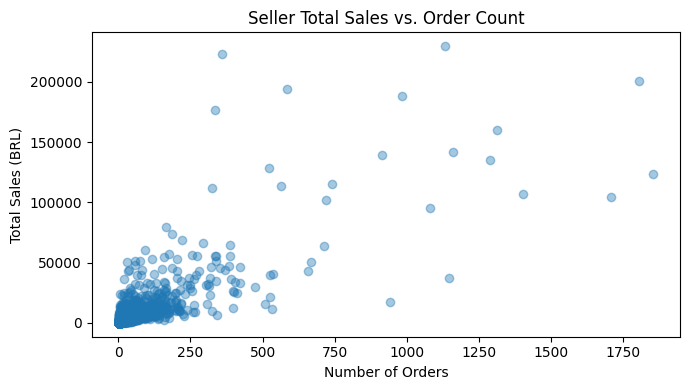

In [10]:
plt.figure(figsize=(7, 4))

plt.scatter(
    seller_metrics["seller_order_count"],
    seller_metrics["seller_total_sales"],
    alpha=0.4
)

plt.title("Seller Total Sales vs. Order Count")
plt.xlabel("Number of Orders")
plt.ylabel("Total Sales (BRL)")

plt.tight_layout()
plt.show()

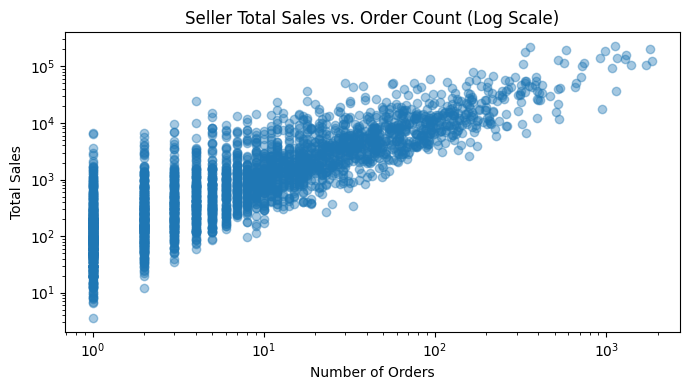

In [11]:
plt.figure(figsize=(7, 4))

plt.scatter(
    seller_metrics["seller_order_count"],
    seller_metrics["seller_total_sales"],
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Seller Total Sales vs. Order Count (Log Scale)")
plt.xlabel("Number of Orders")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Reviews and delivery

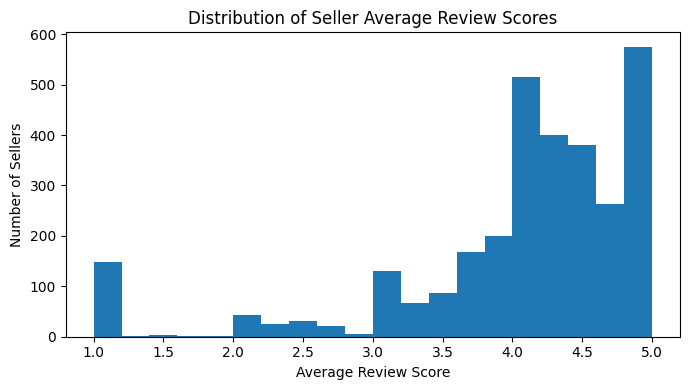

In [12]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_average_review"].dropna(),
    bins=20
)

plt.title("Distribution of Seller Average Review Scores")
plt.xlabel("Average Review Score")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

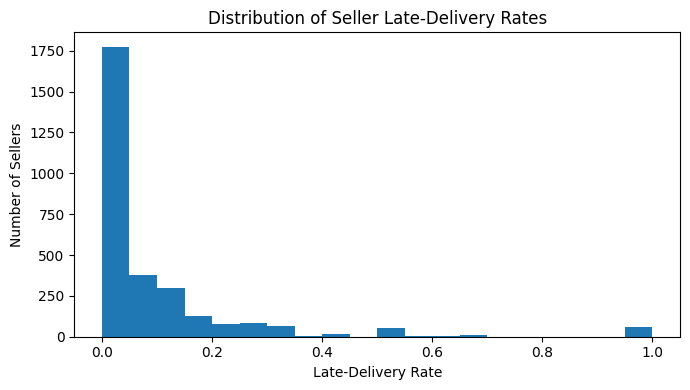

In [13]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_late_delivery_rate"].dropna(),
    bins=20
)

plt.title("Distribution of Seller Late-Delivery Rates")
plt.xlabel("Late-Delivery Rate")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

In [14]:
observation_summary = (
    seller_metrics[
        [
            "seller_reviewed_order_count",
            "seller_delivery_order_count"
        ]
    ]
    .describe()
    .T
    .round(2)
)

display(observation_summary)

,count,mean,std,min,25%,50%,75%,max
seller_reviewed_order_count,3095.0,31.23,102.02,0.0,2.0,6.0,20.0,1807.0
seller_delivery_order_count,3095.0,30.76,101.10,0.0,2.0,6.0,20.0,1788.0


In [15]:
print(
    "Sellers with fewer than 5 reviewed orders:",
    (seller_metrics["seller_reviewed_order_count"] < 5).sum()
)

print(
    "Sellers with fewer than 5 delivery observations:",
    (seller_metrics["seller_delivery_order_count"] < 5).sum()
)

print(
    "Sellers with at least 10 reviewed orders:",
    (seller_metrics["seller_reviewed_order_count"] >= 10).sum()
)

print(
    "Sellers with at least 10 delivery observations:",
    (seller_metrics["seller_delivery_order_count"] >= 10).sum()
)

Sellers with fewer than 5 reviewed orders: 1329
Sellers with fewer than 5 delivery observations: 1353
Sellers with at least 10 reviewed orders: 1244
Sellers with at least 10 delivery observations: 1217


### Observation-count note


Seller-level review and delivery metrics are based on very different numbers of orders across sellers. Approximately 43% of sellers have fewer than five reviewed orders, and approximately 44% have fewer than five valid delivery observations. Therefore, extreme average-review scores and late-delivery rates may sometimes reflect small sample sizes rather than stable seller performance.

All sellers are retained in the full seller dataset and descriptive EDA. For later analyses that rely heavily on average review score or late-delivery rate, I should also conduct a sensitivity analysis using sellers with a minimum number of eligible observations, such as at least 5 or 10 orders. This will allow me to compare the full marketplace with a subset of sellers whose performance measures are based on more consistent amounts of data.

### Product and category variety

In [16]:
print("Product count:")
display(
    seller_metrics["seller_product_count"]
    .describe()
    .round(2)
)

print("\nCategory count:")
display(
    seller_metrics["seller_category_count"]
    .describe()
    .round(2)
)

Product count:


,seller_product_count
count,3095.00
mean,11.13
std,24.47
min,1.00
25%,2.00
50%,4.00
75%,10.00
max,399.00



Category count:


,seller_category_count
count,3095.00
mean,2.05
std,2.10
min,0.00
25%,1.00
50%,1.00
75%,2.00
max,27.00


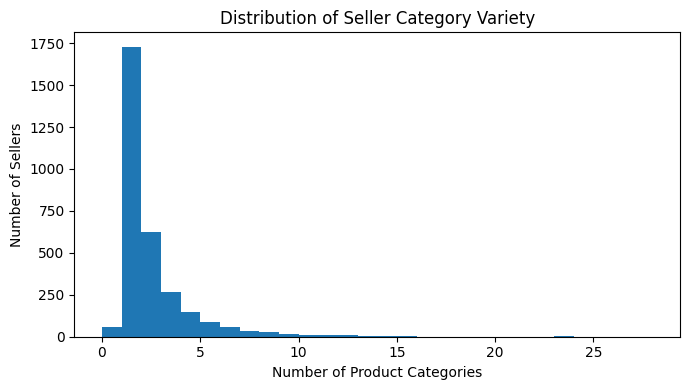

In [17]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_category_count"].dropna(),
    bins=range(
        int(seller_metrics["seller_category_count"].max()) + 2
    )
)

plt.title("Distribution of Seller Category Variety")
plt.xlabel("Number of Product Categories")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

Most sellers have relatively narrow product assortments. The median seller sells four unique products and operates in one product category, while only a small number of sellers span many categories. Product and category variety are both right-skewed.

### Freight

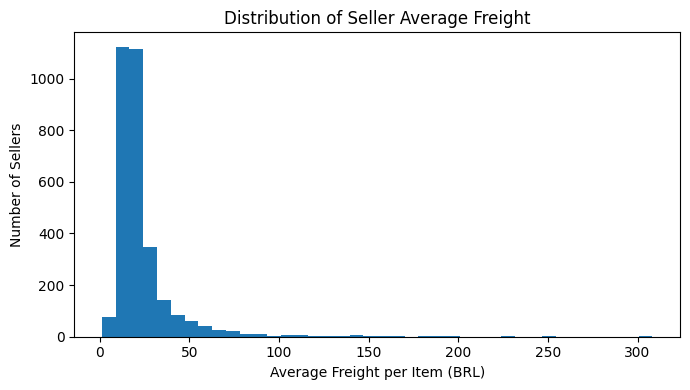

In [18]:
plt.figure(figsize=(7, 4))

plt.hist(
    seller_metrics["seller_avg_freight"].dropna(),
    bins=40
)

plt.title("Distribution of Seller Average Freight")
plt.xlabel("Average Freight per Item (BRL)")
plt.ylabel("Number of Sellers")

plt.tight_layout()
plt.show()

In [19]:
display(
    seller_metrics[
        [
            "seller_id",
            "seller_order_count",
            "seller_avg_freight"
        ]
    ]
    .sort_values("seller_avg_freight", ascending=False)
    .head(10)
)

,seller_id,seller_order_count,seller_avg_freight
1362,6fa9202c10491e472dffd59a3e82b2a3,3,308.336667
2436,c88f62b4c386a59281014d677864d016,1,251.500000
2881,ee27a8f15b1dded4d213a468ba4eb391,1,227.660000
1583,80ceebb4ee9b31afb6c6a916a574a1e2,1,193.210000
1059,56e361f411e38dcef17cdc2a3d99628b,5,185.776000
111,08cdbae123ff67ca4e36d9d641ce0119,4,182.745000
1421,731ef20c231d9a7103a425e83fd91271,2,168.533333
1027,54219883e72aad869adfb2a54b7bfa0f,5,165.910000
282,17f51e7198701186712e53a39c564617,56,160.548033
713,3c88ed2e76a2247933a15daa7161eb1c,1,151.200000


Seller average freight is strongly right-skewed. Several of the largest average freight values belong to sellers with very few orders, so some extreme seller averages may reflect limited transaction history. Extreme values are retained for later investigation rather than removed during EDA.

### Seller geography

In [20]:
seller_state_counts = (
    seller_metrics["seller_state"]
    .value_counts()
)

display(
    seller_state_counts.to_frame("seller_count")
)

,seller_count
seller_state,
SP,1849
PR,349
MG,244
SC,190
RJ,171
RS,129
GO,40
DF,30
ES,23


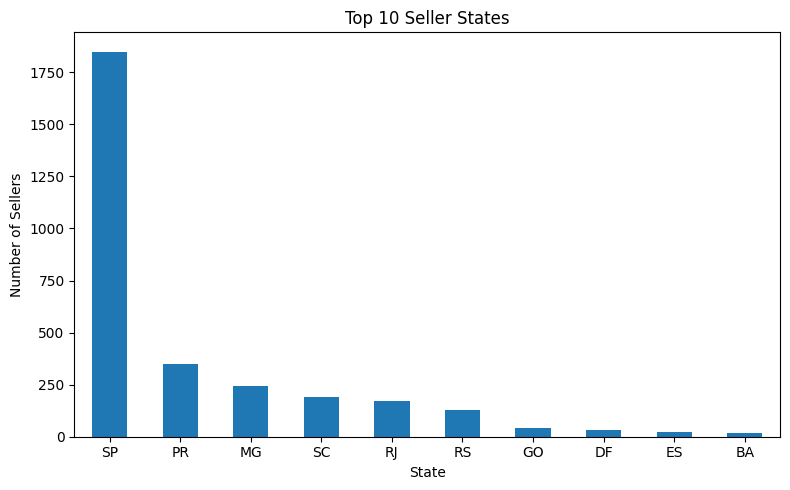

In [21]:
plt.figure(figsize=(8, 5))

seller_state_counts.head(10).plot(kind="bar")

plt.title("Top 10 Seller States")
plt.xlabel("State")
plt.ylabel("Number of Sellers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Seller geography is highly concentrated in São Paulo (SP), which contains 1,849 of the 3,095 sellers. Paraná, Minas Gerais, Santa Catarina, Rio de Janeiro, and Rio Grande do Sul form the next-largest seller groups, while many states contain relatively few sellers. Geographic comparisons will need to account for this imbalance.

# Notes

- Seller-level EDA was conducted using `seller_metrics.csv`, which contains one row per seller.
- The dataset contains 3,095 unique sellers with no duplicate seller IDs.
- Seller activity is highly right-skewed across order count, items sold, total sales, freight, product count, and category count.
- The median seller has 6 orders, sells 8 items, and generates about 821 BRL in total sales.
- Seller total sales generally increase with order count, although sellers with similar order volumes can still have different sales values.
- Seller average review scores are generally high, with a median of about 4.24 out of 5.
- Seller late-delivery rates are generally low, with a median of 0 and a mean of about 9%, but some sellers have much higher rates.
- Seller review and delivery measures are based on uneven numbers of observations across sellers.
- 1,329 sellers have fewer than 5 reviewed orders, and 1,353 sellers have fewer than 5 valid delivery observations.
- All sellers are retained for descriptive EDA, but later analysis may also compare sellers with at least 5 or 10 eligible observations to evaluate whether small sample sizes affect the results.
- Most sellers have relatively narrow product assortments. The median seller sells 4 unique products and operates in 1 product category.
- Seller average freight is right-skewed, and several of the highest average freight values belong to sellers with relatively few orders.
- Seller geography is highly concentrated in São Paulo (SP), which contains 1,849 of the 3,095 sellers.
- Geographic comparisons should account for the large differences in seller counts across states.
- Extreme values were retained during EDA rather than automatically removed so their influence can be evaluated later.